# STalign parity: `xenium-xenium-alignment.ipynb`

Executed one-to-one replay of [the pinned upstream notebook](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/xenium-xenium-alignment.ipynb).

Status: `compared`. The two sections overlap only partially. Unmatched cells are expected; the matching-weight panels identify the supported overlap. Both passes skipped 4 cell(s) unrelated to the fit -- cell 48: TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.; cell 49: TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.; cell 50: RuntimeError: indices should be either on cpu or on the same device as the indexed tensor (cpu); cell 51: RuntimeError: indices should be either on cpu or on the same device as the indexed tensor (cpu)


In [1]:
# per-variable relative L2: upstream STalign vs the squidpy JAX port


{
  "A relative L2": 8.76424708471137e-06,
  "AI relative L2": 0.0,
  "L relative L2": 0.0,
  "WM relative L2": 5.806357635728792e-16,
  "df1 relative L2": 0.0,
  "df2 relative L2": 0.0,
  "extentI relative L2": 0.0,
  "extentJ relative L2": 0.0,
  "levels relative L2": 0.0,
  "phi relative L2": 7.225870859960842e-06,
  "phiI relative L2": 0.00012017795643962407,
  "phii relative L2": 7.803846103864998e-06,
  "phiiJ relative L2": 0.0001349704995420719,
  "phiipointsJ relative L2": 6.428087989952521e-06,
  "phipointsI relative L2": 7.373213496560565e-06,
  "pointsI relative L2": 0.0,
  "pointsJ relative L2": 0.0,
  "results relative L2": 6.296653855497429e-07,
  "testM relative L2": 7.377139991149306e-05,
  "tpointsI relative L2": 7.57791284095799e-06,
  "tpointsJ relative L2": 7.956055684871315e-06,
  "v relative L2": 4.43680933745319e-15
}

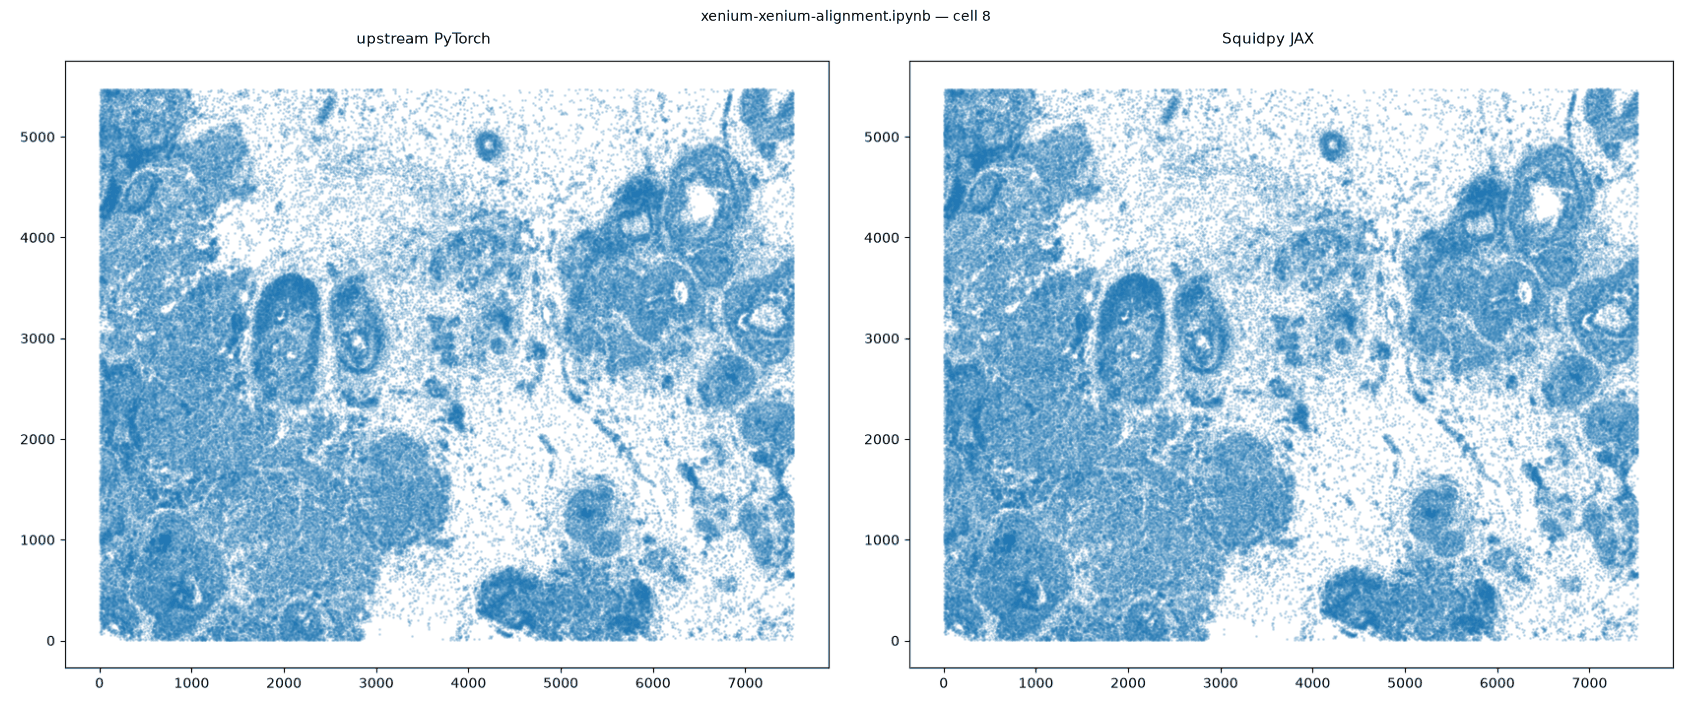

In [2]:
# get cell centroid coordinates
xI = np.array(df1['x_centroid'])
yI = np.array(df1['y_centroid'])

# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2)

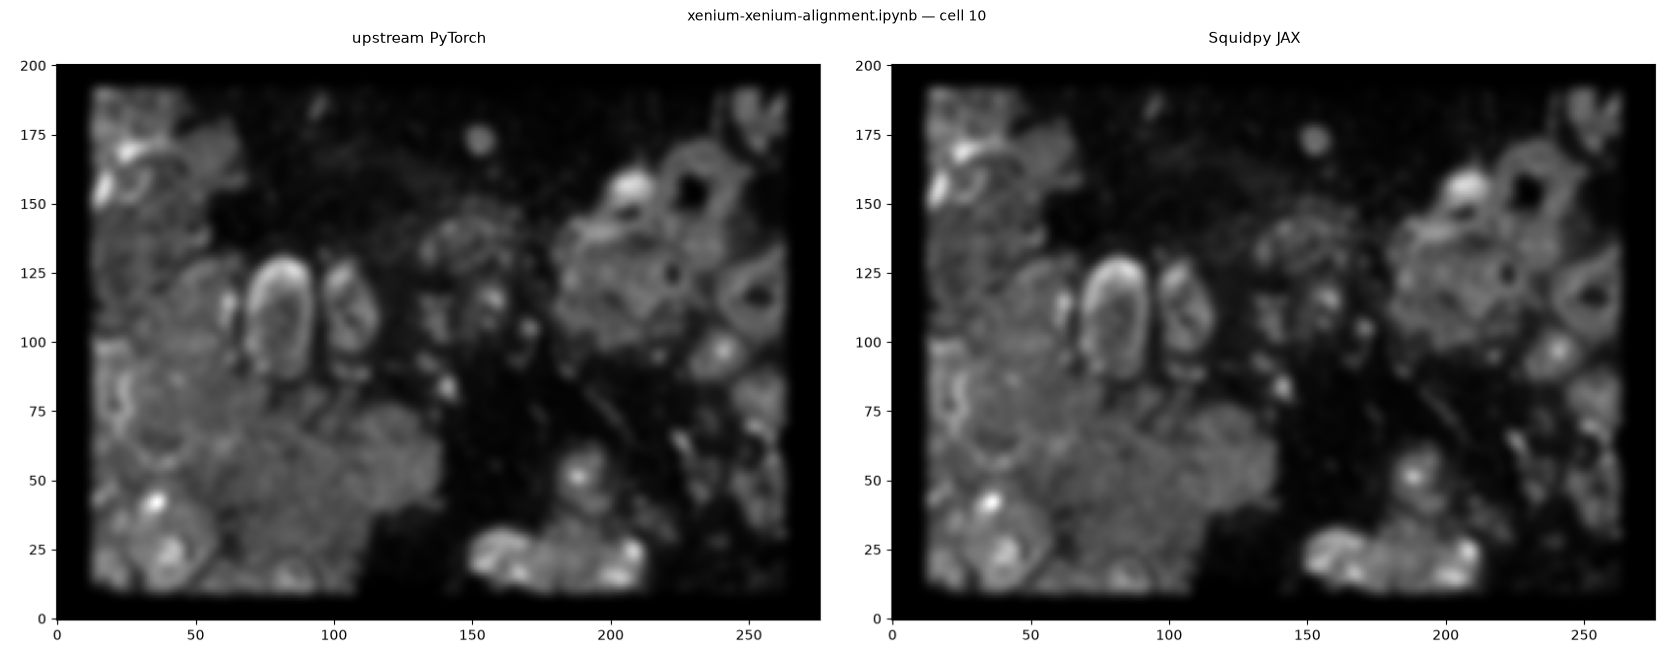

In [3]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XI,YI,I,fig = STalign.rasterize(xI,yI,dx=30)

# plot
ax = fig.axes[0]
ax.invert_yaxis()

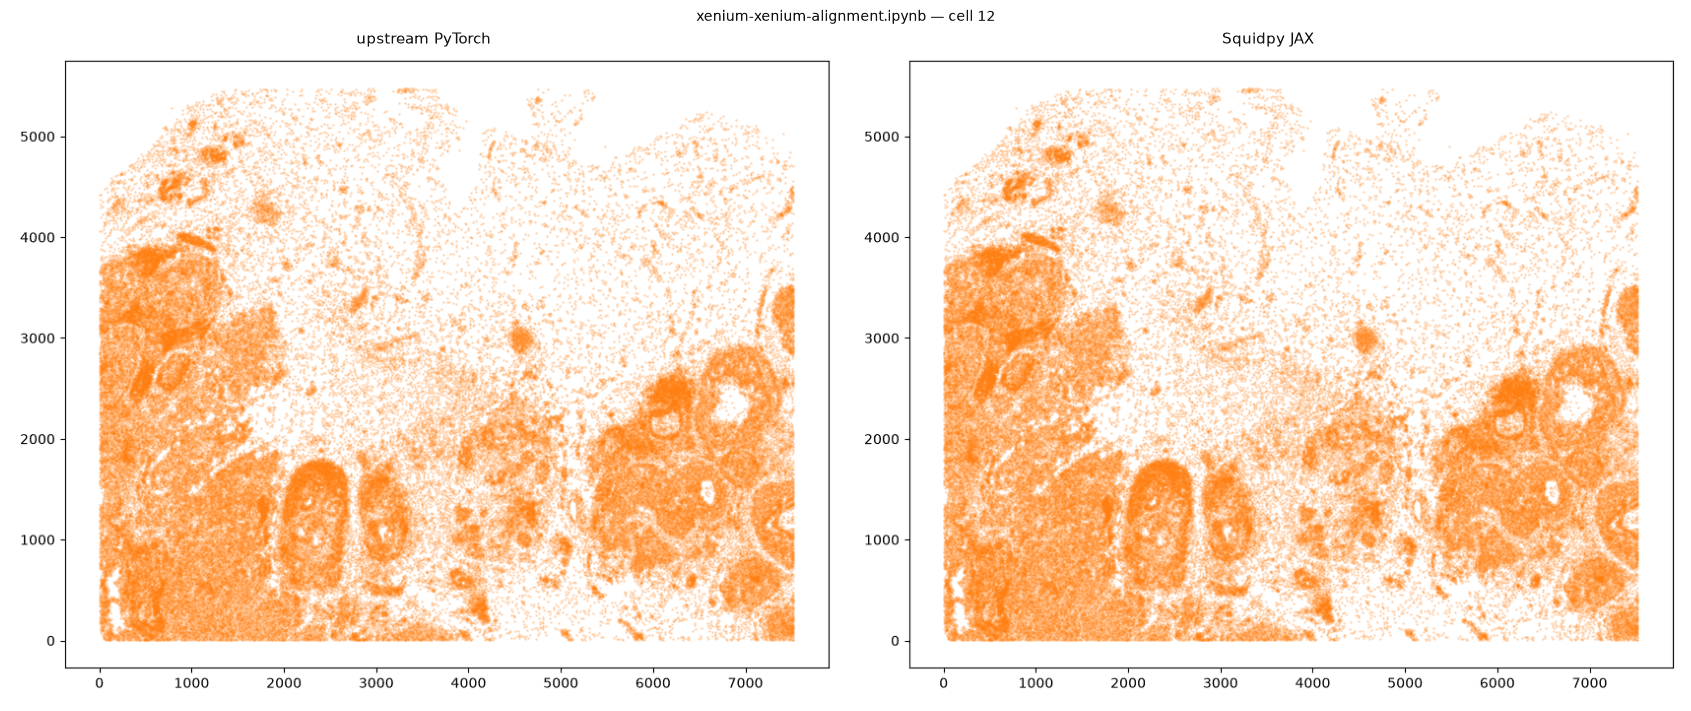

In [4]:
# Single cell data 2
# read in data
fname = '../xenium_data/Xenium_FFPE_Human_Breast_Cancer_Rep2_cells.csv.gz'
df2 = pd.read_csv(fname)

# get cell centroids
xJ = np.array(df2['x_centroid'])
yJ = np.array(df2['y_centroid'])

# plot
fig,ax = plt.subplots()
ax.scatter(xJ,yJ,s=1,alpha=0.2,c='#ff7f0e')

# rasterize and plot
XJ,YJ,J,fig = STalign.rasterize(xJ,yJ,dx=30)
ax = fig.axes[0]
ax.invert_yaxis()

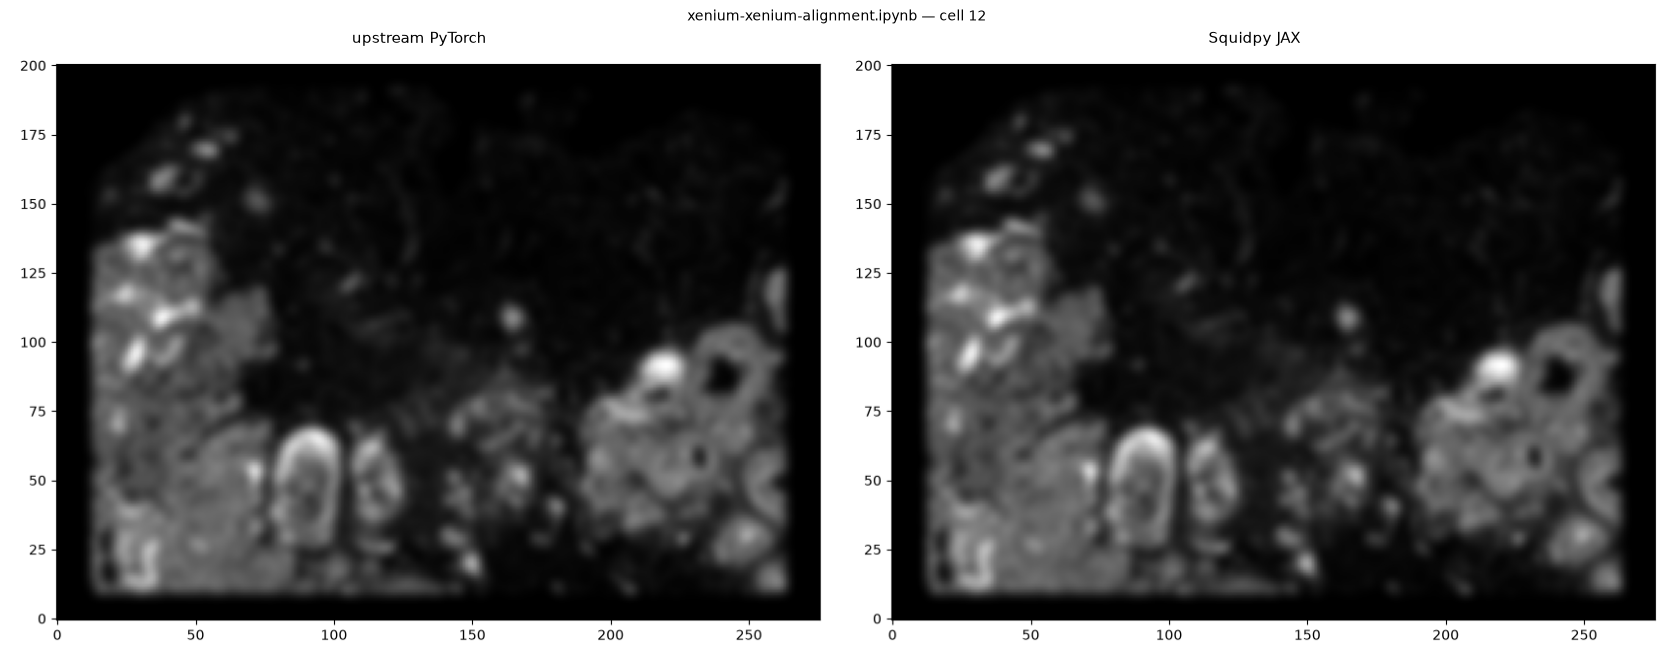

In [5]:
# Single cell data 2
# read in data
fname = '../xenium_data/Xenium_FFPE_Human_Breast_Cancer_Rep2_cells.csv.gz'
df2 = pd.read_csv(fname)

# get cell centroids
xJ = np.array(df2['x_centroid'])
yJ = np.array(df2['y_centroid'])

# plot
fig,ax = plt.subplots()
ax.scatter(xJ,yJ,s=1,alpha=0.2,c='#ff7f0e')

# rasterize and plot
XJ,YJ,J,fig = STalign.rasterize(xJ,yJ,dx=30)
ax = fig.axes[0]
ax.invert_yaxis()

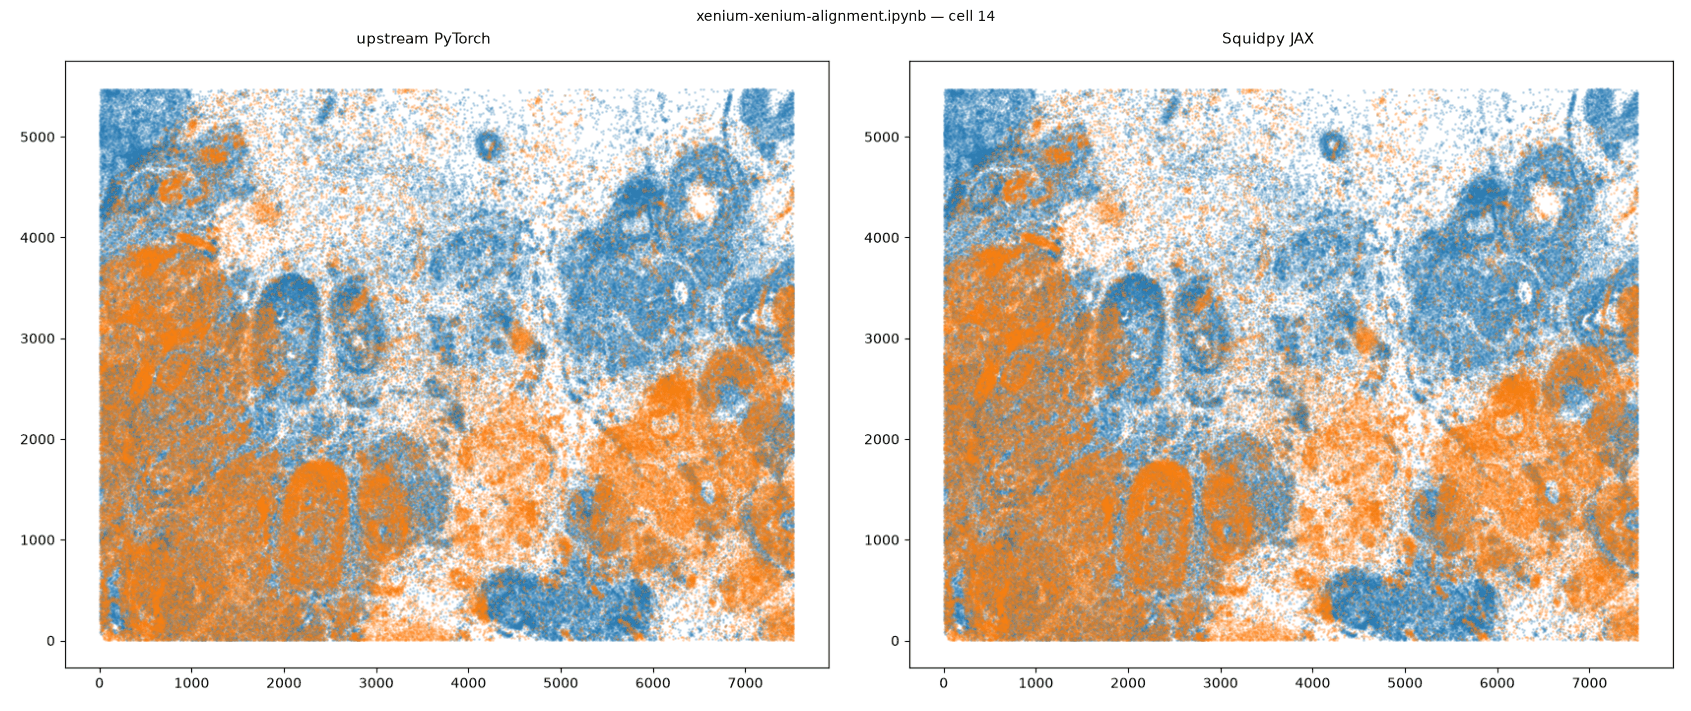

In [6]:
# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2)
ax.scatter(xJ,yJ,s=1,alpha=0.2)

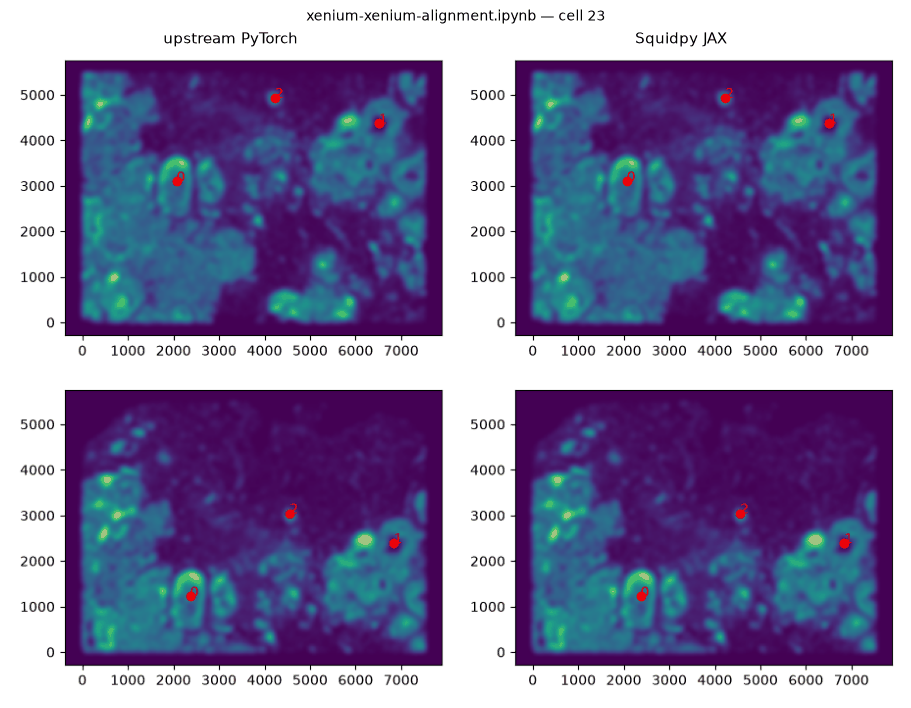

In [7]:
# get extent of images
extentI = STalign.extent_from_x((YI,XI))
extentJ = STalign.extent_from_x((YJ,XJ))

# plot rasterized images
fig,ax = plt.subplots(2,1)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI) # just want 201x276 matrix
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ) # just want 201x276 matrix
# with points
ax[0].scatter(pointsI[:,1], pointsI[:,0], c='red')
ax[1].scatter(pointsJ[:,1], pointsJ[:,0], c='red')
for i in range(pointsI.shape[0]):
    ax[0].text(pointsI[i,1],pointsI[i,0],f'{i}', c='red')
    ax[1].text(pointsJ[i,1],pointsJ[i,0],f'{i}', c='red')
ax[0].invert_yaxis()
ax[1].invert_yaxis()

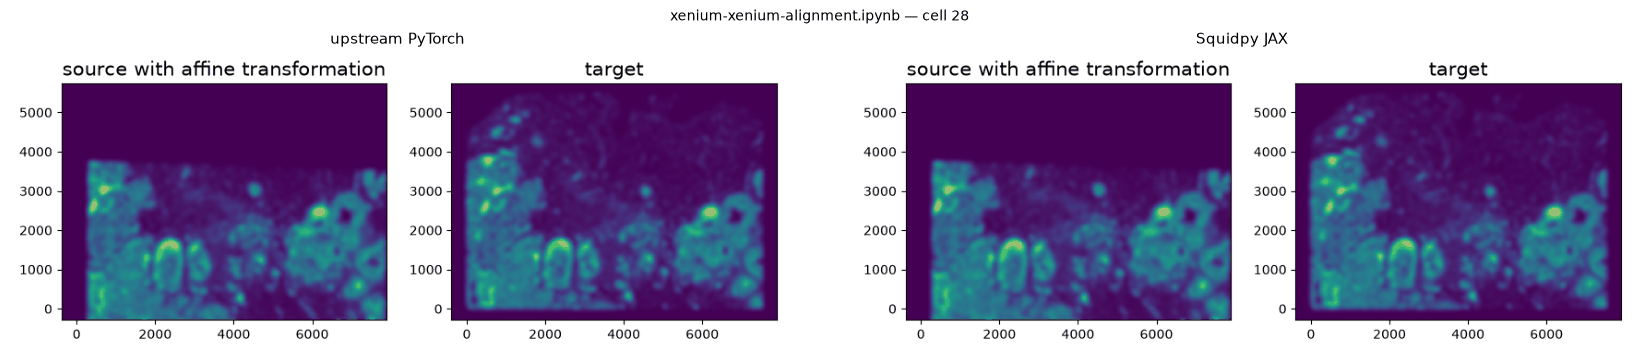

In [8]:
# compute initial affine transformation from points
AI = STalign.transform_image_source_with_A(A, [YI,XI], I, [YJ,XJ])

#switch tensor from cuda to cpu for plotting with numpy
if AI.is_cuda:
    AI = AI.cpu()

fig,ax = plt.subplots(1,2)
ax[0].imshow((AI.permute(1,2,0).squeeze()), extent=extentJ)
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

ax[0].set_title('source with affine transformation', fontsize=15)
ax[1].set_title('target', fontsize=15)

ax[0].invert_yaxis()
ax[1].invert_yaxis()

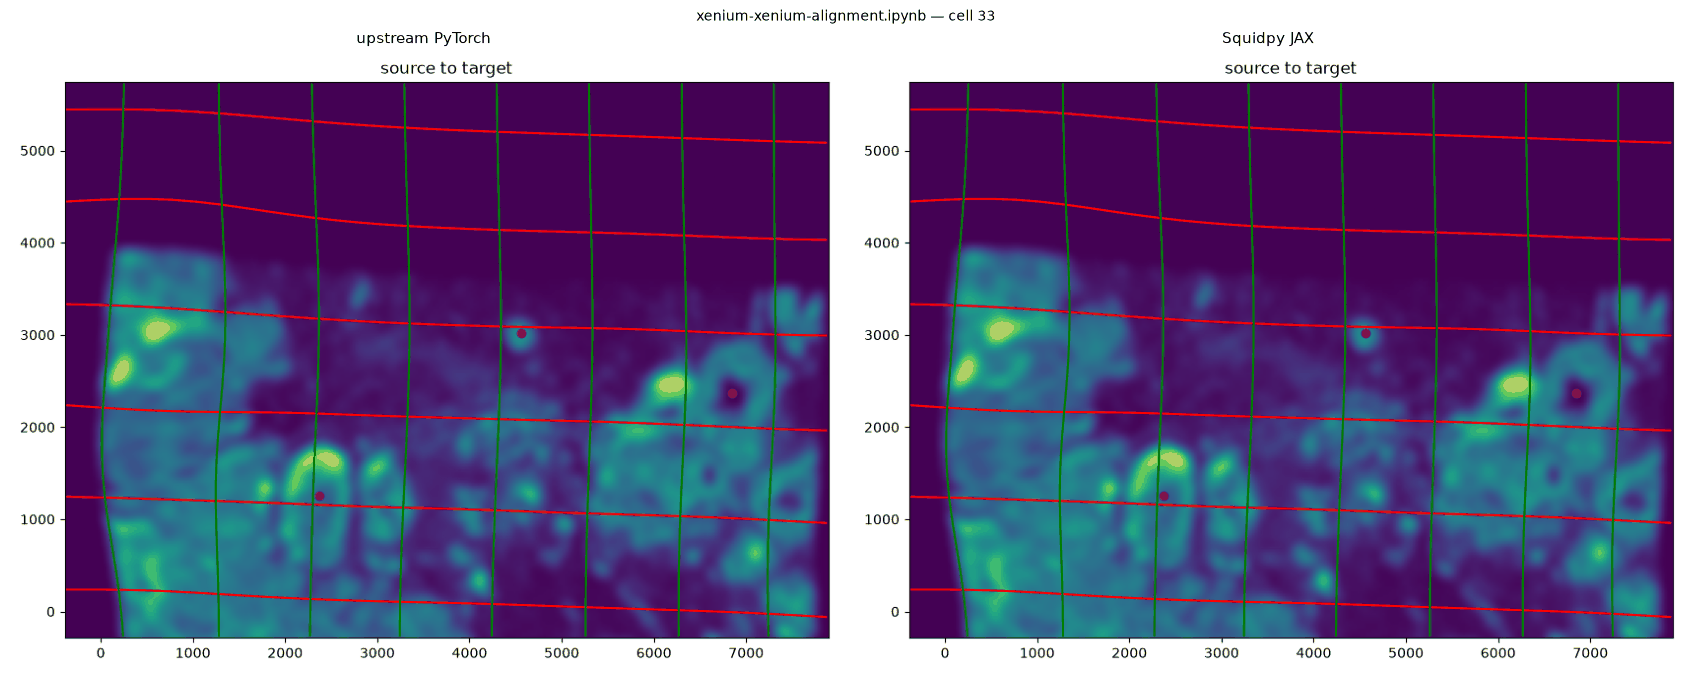

In [9]:
# apply transform
phii = STalign.build_transform(xv,v,A,XJ=[YJ,XJ],direction='b')
phiI = STalign.transform_image_source_to_target(xv,v,A,[YI,XI],I,[YJ,XJ])
phipointsI = STalign.transform_points_source_to_target(xv,v,A,pointsI)

#switch tensor from cuda to cpu for plotting with numpy
if phii.is_cuda:
    phii = phii.cpu()
if phiI.is_cuda:
    phiI = phiI.cpu()
if phipointsI.is_cuda:
    phipointsI = phipointsI.cpu()

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-100000,100000,1000)
ax.contour(XJ,YJ,phii[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XJ,YJ,phii[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('source to target')
ax.imshow(phiI.permute(1,2,0)/torch.max(phiI),extent=extentJ)
ax.scatter(phipointsI[:,1].detach(),phipointsI[:,0].detach(),c="m")
ax.invert_yaxis()

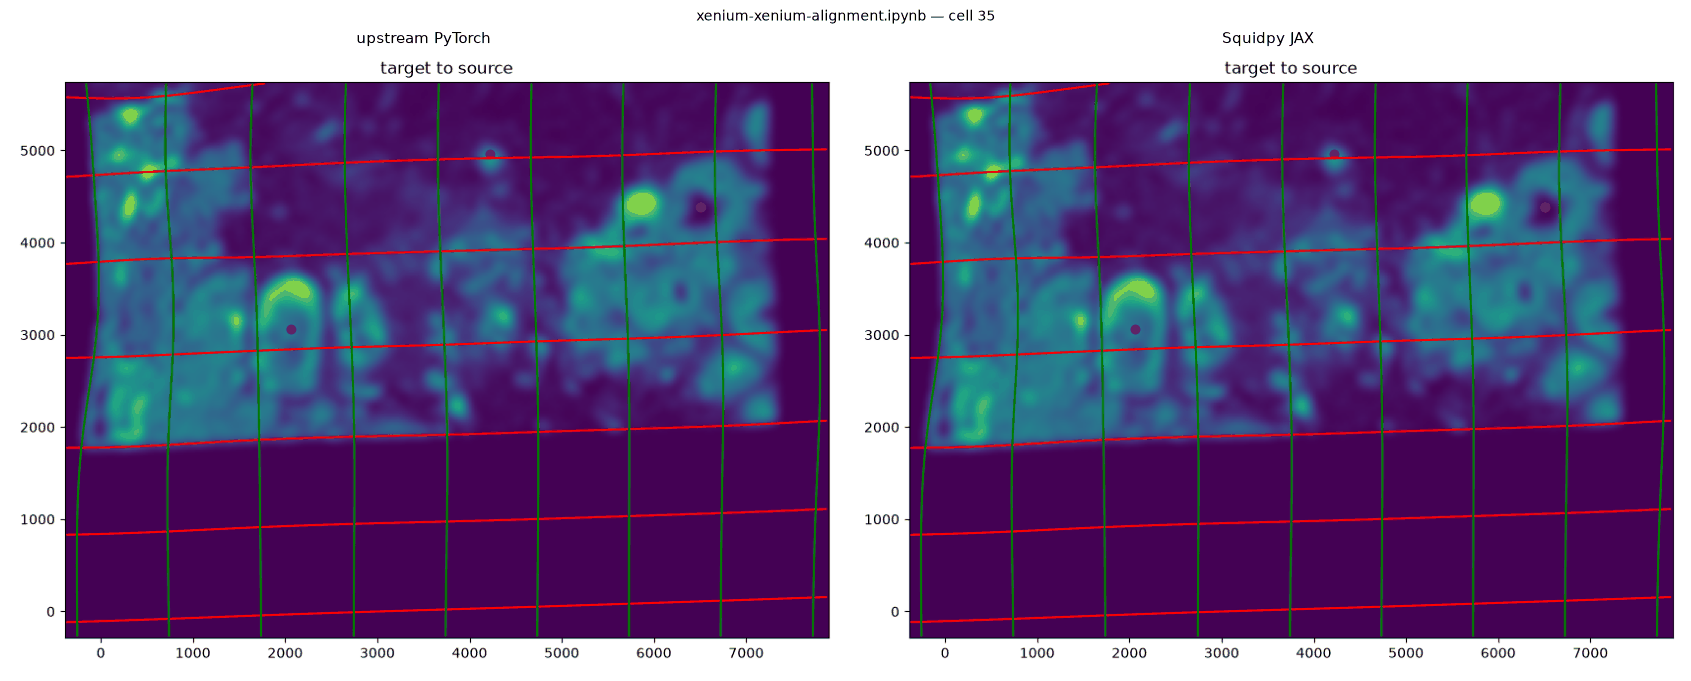

In [10]:
# transform is invertible
phi = STalign.build_transform(xv,v,A,XJ=[YI,XI],direction='f')
phiiJ = STalign.transform_image_target_to_source(xv,v,A,[YJ,XJ],J,[YI,XI])
phiipointsJ = STalign.transform_points_target_to_source(xv,v,A,pointsJ)

#switch tensor from cuda to cpu for plotting with numpy
if phi.is_cuda:
    phi = phi.cpu()
if phiiJ.is_cuda:
    phiiJ = phiiJ.cpu()
if phiipointsJ.is_cuda:
    phiipointsJ = phiipointsJ.cpu()

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-100000,100000,1000)
ax.contour(XI,YI,phi[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XI,YI,phi[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('target to source')
ax.imshow(phiiJ.permute(1,2,0)/torch.max(phiiJ),extent=extentI)
ax.scatter(phiipointsJ[:,1].detach(),phiipointsJ[:,0].detach(),c="m")
ax.invert_yaxis()

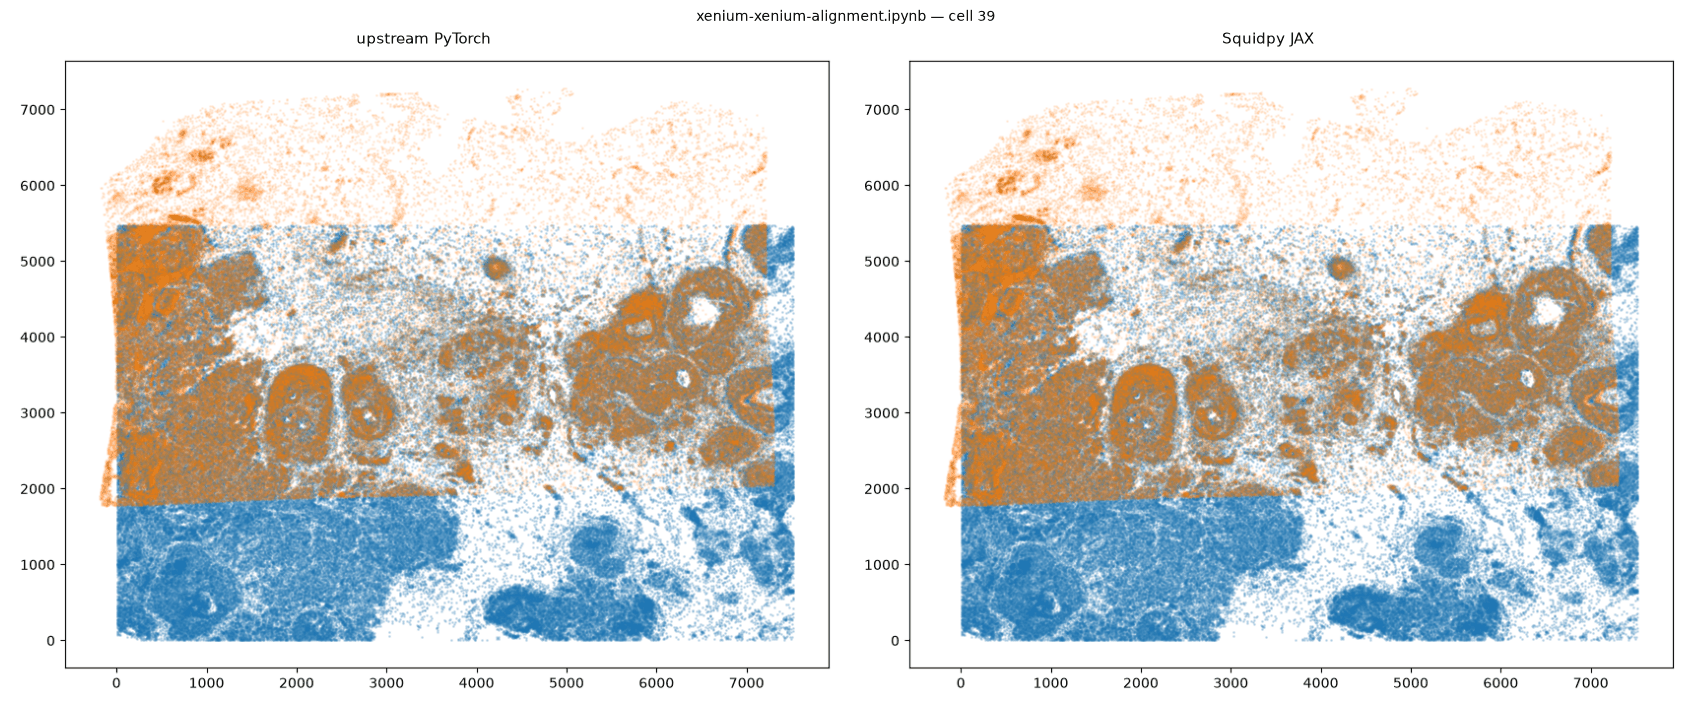

In [11]:
# plot results
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2) 
ax.scatter(tpointsJ[:,1],tpointsJ[:,0],s=1,alpha=0.1) # also needs to plot as y,x not x,y

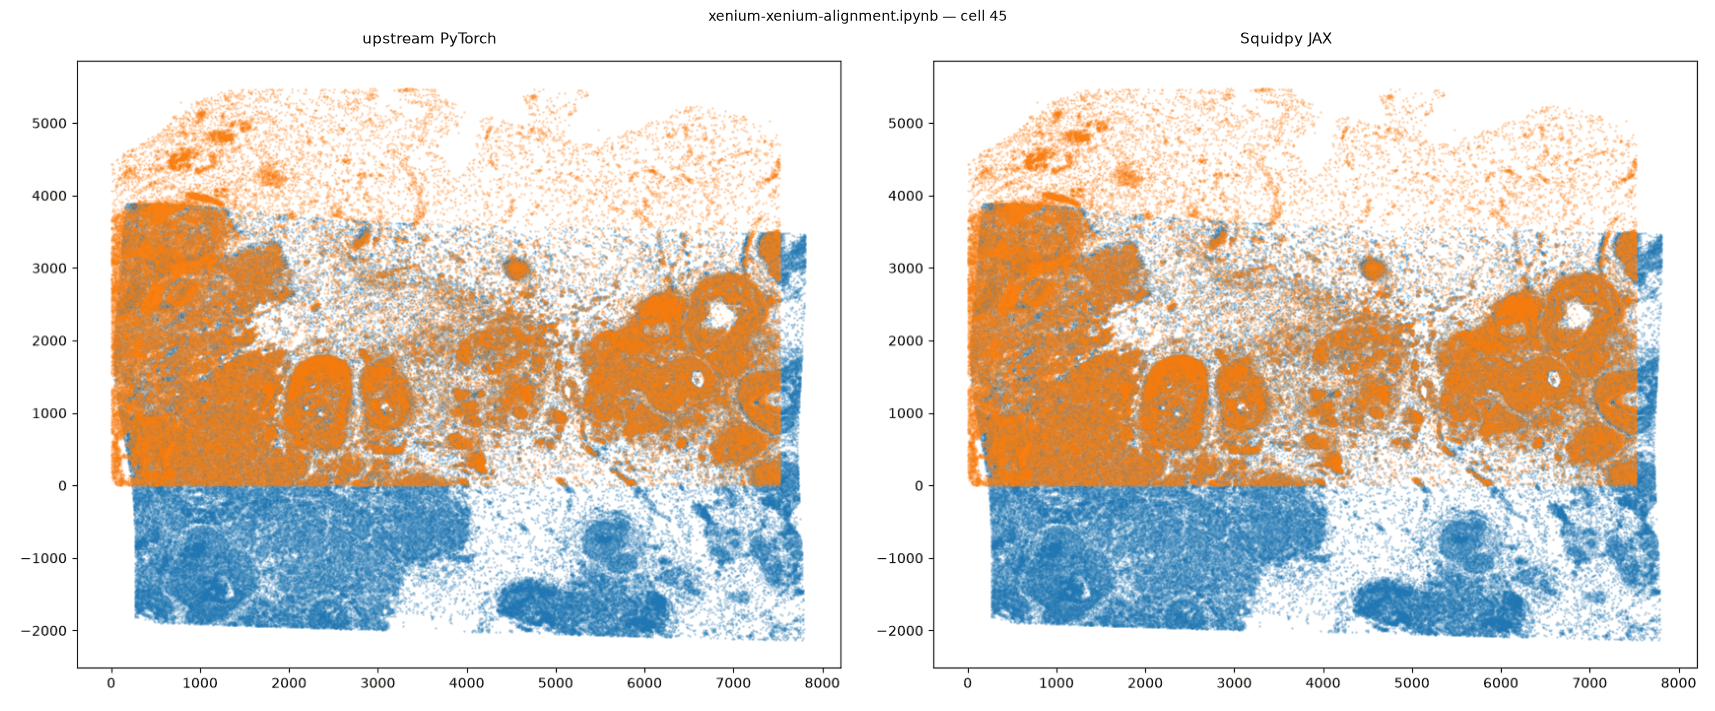

In [12]:
# apply transform to original points of source to target
tpointsI = STalign.transform_points_source_to_target(xv,v,A, np.stack([yI, xI], 1))

#switch tensor from cuda to cpu for plotting with numpy
if tpointsI.is_cuda:
    tpointsI = tpointsI.cpu()
    
# plot results
fig,ax = plt.subplots() 
ax.scatter(tpointsI[:,1],tpointsI[:,0],s=1,alpha=0.2) # also needs to plot as y,x not x,y
ax.scatter(xJ,yJ,s=1,alpha=0.2)